# UPI Transaction Failure Root-Cause Intelligence System (Interactive)
### Kishan Patel (251370680017)
### Internal Guide: Komal Prajapati

This notebook is designed for **visual + real-time understanding** and follows all sections from the PDF:
1. Identification of Broad Area of Problem
2. Dataset Description
3. Results Visualization and Comparison (with preprocessing notes)
4. Usefulness and Limitation of Work
5. Timeline Chart
6. References

> Educational use: synthetic data generated in-notebook (no upload needed).


## 1) Identification of Broad Area of Problem

- Domain: FinTech digital payments and transaction analytics.
- UPI processes very high transaction volume; failure diagnosis remains critical.
- Problem statement: classify **root cause** of failed transactions using ML over logs, error metadata, and system indicators.

### Target root-cause classes (8)
- Bank_Server_Down
- Insufficient_Funds
- Wrong_Credentials
- Network_Timeout
- VPA_Not_Found
- Fraud_Flag
- NPCI_Gateway_Error
- User_Declined


In [ ]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.3 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import ipywidgets as widgets
from IPython.display import display, clear_output

sns.set_style('whitegrid')
np.random.seed(42)
print('Libraries loaded.')


Libraries loaded.


## 2) Dataset Description

As required in the PDF, we simulate a UPI log with these properties:
- ~100,000 transactions
- ~72% success, ~28% failure
- 8 failure root-cause classes
- Imbalanced failures (Bank_Server_Down and Network_Timeout dominate; Fraud_Flag is rare)

### Feature coverage (representative)
Transaction ID, timestamp, amount, payer/payee VPA bucket, payer/payee bank, transaction type, device OS, network type, error code, response time, retry count, hour/day fields, bank server status, NPCI gateway latency.


In [ ]:
N_TRANSACTIONS = 100_000  # reduce to 25_000 if runtime is slow

ROOT_CAUSES = [
    'Bank_Server_Down', 'Insufficient_Funds', 'Wrong_Credentials', 'Network_Timeout',
    'VPA_Not_Found', 'Fraud_Flag', 'NPCI_Gateway_Error', 'User_Declined'
]
FAIL_P = np.array([0.38, 0.10, 0.08, 0.27, 0.07, 0.02, 0.05, 0.03])

BANKS = ['SBI', 'HDFC', 'ICICI', 'AXIS', 'PNB', 'BOB', 'Canara', 'Kotak', 'Yes', 'IDFC']
DEVICE_OS = ['Android', 'iOS', 'Web']
NETWORKS = ['4G', 'WiFi', '3G']
TXN_TYPES = ['P2P', 'P2M']
ERRORS = ['NA', 'E001', 'E002', 'E003', 'E004', 'E005', 'E006', 'E007', 'E008']

n = N_TRANSACTIONS
is_success = (np.random.rand(n) < 0.72)

root = np.array([None] * n, dtype=object)
fail_idx = np.where(~is_success)[0]
root[fail_idx] = np.random.choice(ROOT_CAUSES, size=len(fail_idx), p=FAIL_P)

df = pd.DataFrame({
    'transaction_id': np.arange(1, n + 1),
    'timestamp': pd.Timestamp('2024-06-01') + pd.to_timedelta(np.random.randint(0, 30*24*3600, n), unit='s'),
    'amount': np.clip(np.random.lognormal(4.2, 1.1, n), 1, 500000).round(2),
    'payer_vpa_bucket': np.random.randint(0, 500, n).astype(float),
    'payee_vpa_bucket': np.random.randint(0, 500, n).astype(float),
    'payer_bank': np.random.choice(BANKS, n),
    'payee_bank': np.random.choice(BANKS, n),
    'transaction_type': np.random.choice(TXN_TYPES, n, p=[0.62, 0.38]),
    'device_os': np.random.choice(DEVICE_OS, n, p=[0.72, 0.25, 0.03]),
    'network_type': np.random.choice(NETWORKS, n, p=[0.55, 0.35, 0.10]),
    'error_code': np.where(is_success, 'NA', np.random.choice(ERRORS[1:], n)),
    'response_time_ms': np.random.gamma(2.0, 450, n),
    'retry_count': np.random.poisson(0.35, n),
    'hour': np.random.randint(0, 24, n),
    'day_of_week': np.random.randint(0, 7, n),
    'bank_server_status': np.random.choice(['healthy', 'degraded', 'down'], n, p=[0.88, 0.09, 0.03]),
    'npci_gateway_latency_ms': np.random.gamma(1.5, 32, n),
    'is_success': is_success.astype(int),
    'root_cause': root,
})

# Inject realistic class signals
for cls in ROOT_CAUSES:
    m = df['root_cause'] == cls
    if cls == 'Network_Timeout':
        df.loc[m, 'response_time_ms'] += np.random.uniform(2200, 5500, m.sum())
        df.loc[m, 'network_type'] = np.random.choice(NETWORKS, m.sum(), p=[0.25, 0.25, 0.50])
    elif cls == 'Bank_Server_Down':
        df.loc[m, 'bank_server_status'] = np.random.choice(['degraded', 'down'], m.sum(), p=[0.35, 0.65])
        df.loc[m, 'payer_bank'] = np.random.choice(['SBI', 'PNB', 'BOB', 'Canara'], m.sum(), p=[0.35, 0.25, 0.25, 0.15])
        df.loc[m, 'response_time_ms'] += np.random.uniform(700, 3000, m.sum())
    elif cls == 'Insufficient_Funds':
        df.loc[m, 'amount'] *= np.random.uniform(1.2, 2.4, m.sum())
    elif cls == 'Wrong_Credentials':
        df.loc[m, 'retry_count'] += np.random.randint(1, 5, m.sum())
    elif cls == 'Fraud_Flag':
        df.loc[m, 'amount'] *= np.random.uniform(2.0, 4.0, m.sum())
    elif cls == 'NPCI_Gateway_Error':
        df.loc[m, 'npci_gateway_latency_ms'] += np.random.uniform(120, 380, m.sum())
        df.loc[m, 'response_time_ms'] += np.random.uniform(450, 2200, m.sum())

# Missing values (for preprocessing section)
miss_vpa = np.random.rand(n) < 0.008
miss_err = (np.random.rand(n) < 0.006) & (df['is_success'] == 0)
miss_rt = np.random.rand(n) < 0.01

df.loc[miss_vpa, 'payer_vpa_bucket'] = np.nan
df.loc[miss_err, 'error_code'] = np.nan
df.loc[miss_rt, 'response_time_ms'] = np.nan

df.to_csv('kishan_upi_synthetic_full.csv', index=False)

print('Full data shape:', df.shape)
print('Success rate:', round(df['is_success'].mean(), 3))
print('Failure rate:', round(1 - df['is_success'].mean(), 3))


Full data shape: (100000, 19)
Success rate: 0.721
Failure rate: 0.279


## 3) Data Preprocessing and Visualization

PDF-required preprocessing steps implemented:
1. Drop rows with null VPA or error code (for failed txns)
2. Median imputation for response time
3. Label encoding for bank names
4. One-hot encoding for network/device/transaction type
5. SMOTE for minority classes
6. Feature engineering: peak_hour, weekend, bank_load_index
7. Standard scaling on numeric features


In [ ]:
df_fail = df[df['is_success'] == 0].dropna(subset=['payer_vpa_bucket', 'error_code']).copy()
df_fail['response_time_ms'] = df_fail['response_time_ms'].fillna(df_fail['response_time_ms'].median())

# Feature engineering
df_fail['peak_hour'] = (((df_fail['hour'] >= 9) & (df_fail['hour'] <= 11)) | ((df_fail['hour'] >= 18) & (df_fail['hour'] <= 21))).astype(int)
df_fail['weekend'] = (df_fail['day_of_week'] >= 5).astype(int)

bank_counts = df_fail['payer_bank'].value_counts()
total_fail = len(df_fail)
df_fail['bank_load_index'] = df_fail['payer_bank'].map(lambda b: bank_counts.get(b, 0) / total_fail)

# Label encoding bank names
le_payer = LabelEncoder()
le_payee = LabelEncoder()
df_fail['payer_bank_le'] = le_payer.fit_transform(df_fail['payer_bank'].astype(str))
df_fail['payee_bank_le'] = le_payee.fit_transform(df_fail['payee_bank'].astype(str))

# Model frame
y = df_fail['root_cause']
X = df_fail.drop(columns=['root_cause', 'is_success', 'transaction_id', 'timestamp', 'payer_bank', 'payee_bank'])

num_cols = ['amount', 'response_time_ms', 'retry_count', 'hour', 'day_of_week',
            'npci_gateway_latency_ms', 'payer_vpa_bucket', 'payee_vpa_bucket',
            'bank_load_index', 'payer_bank_le', 'payee_bank_le', 'peak_hour', 'weekend']
cat_cols = ['network_type', 'device_os', 'transaction_type', 'bank_server_status', 'error_code']

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Failed txns after cleaning:', len(df_fail))
print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Class distribution:')
print(y.value_counts(normalize=True).round(3))

Failed txns after cleaning: 27471
Train: (21976, 18) | Test: (5495, 18)
Class distribution:
root_cause
Bank_Server_Down      0.383
Network_Timeout       0.268
Insufficient_Funds    0.099
Wrong_Credentials     0.080
VPA_Not_Found         0.073
NPCI_Gateway_Error    0.048
User_Declined         0.029
Fraud_Flag            0.020
Name: proportion, dtype: float64


### 3.1 Visualization Insights (as in PDF)


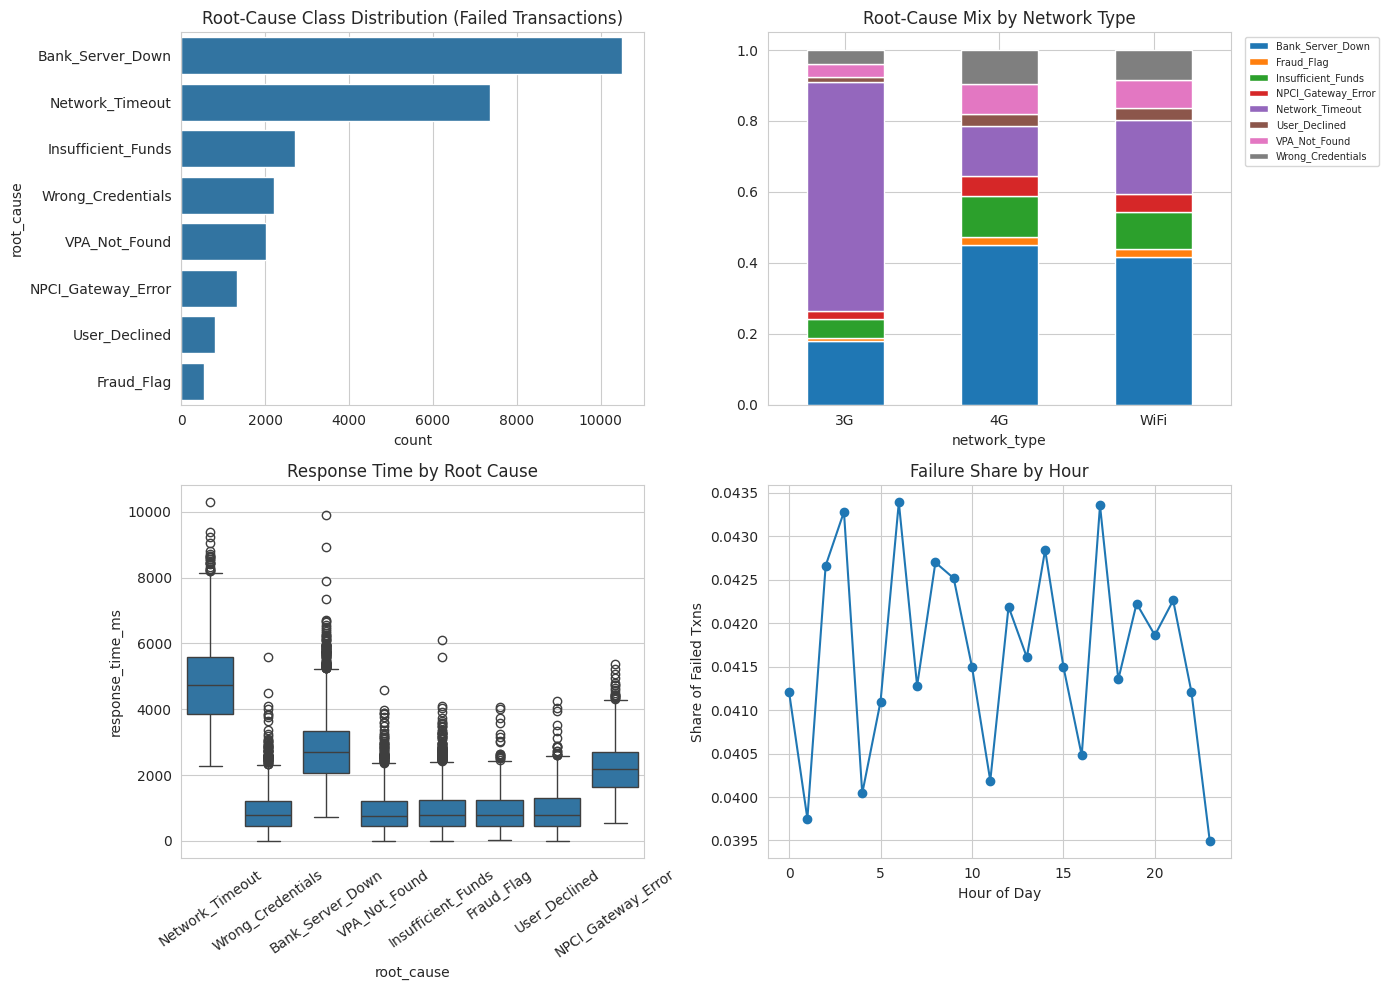

Insight check:
- High response time strongly aligns with Network_Timeout.
- 3G has higher timeout concentration than WiFi/4G.
- Peak windows show elevated failure concentration.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_fail, y='root_cause', order=df_fail['root_cause'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Root-Cause Class Distribution (Failed Transactions)')

net_ct = pd.crosstab(df_fail['network_type'], df_fail['root_cause'], normalize='index')
net_ct.plot(kind='bar', stacked=True, ax=axes[0, 1], legend=False)
axes[0, 1].set_title('Root-Cause Mix by Network Type')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(bbox_to_anchor=(1.02, 1), fontsize=7)

sns.boxplot(data=df_fail, x='root_cause', y='response_time_ms', ax=axes[1, 0])
axes[1, 0].set_title('Response Time by Root Cause')
axes[1, 0].tick_params(axis='x', rotation=35)

hourly_fail = df_fail.groupby('hour').size()
(hourly_fail / hourly_fail.sum()).plot(ax=axes[1, 1], marker='o')
axes[1, 1].set_title('Failure Share by Hour')
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Share of Failed Txns')

plt.tight_layout()
plt.show()

print('Insight check:')
print('- High response time strongly aligns with Network_Timeout.')
print('- 3G has higher timeout concentration than WiFi/4G.')
print('- Peak windows show elevated failure concentration.')


## 4) Results Visualization and Comparison

To keep understanding simple and practical, we compare:
- Baseline: Logistic Regression
- Main model: Random Forest (with SMOTE)

This gives clear accuracy/F1 comparison while retaining interpretability.


LogisticRegression: Accuracy=0.7955, Macro_F1=0.5741
RandomForest: Accuracy=0.8273, Macro_F1=0.5782


,Model,Accuracy,Macro_F1
1,RandomForest,0.827298,0.578169
0,LogisticRegression,0.795450,0.574138


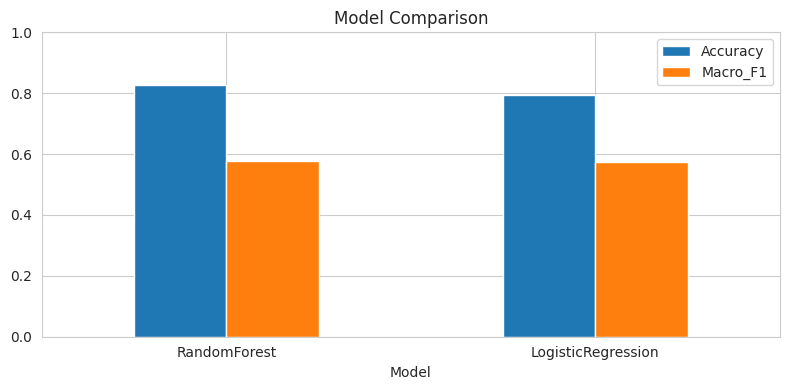

Best model selected: RandomForest


In [ ]:
from sklearn.linear_model import LogisticRegression

pipe_lr = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=1200, multi_class='multinomial')),
])

pipe_rf = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(n_estimators=180, max_depth=20, random_state=42, n_jobs=-1)),
])

models = {'LogisticRegression': pipe_lr, 'RandomForest': pipe_rf}
results = []
trained = {}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average='macro')
    results.append({'Model': name, 'Accuracy': acc, 'Macro_F1': f1m})
    trained[name] = pipe
    print(f"{name}: Accuracy={acc:.4f}, Macro_F1={f1m:.4f}")

res = pd.DataFrame(results).sort_values('Macro_F1', ascending=False)
display(res)

ax = res.plot(x='Model', y=['Accuracy', 'Macro_F1'], kind='bar', figsize=(8, 4), rot=0)
ax.set_title('Model Comparison')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

best_name = res.iloc[0]['Model']
best_model = trained[best_name]
print('Best model selected:', best_name)


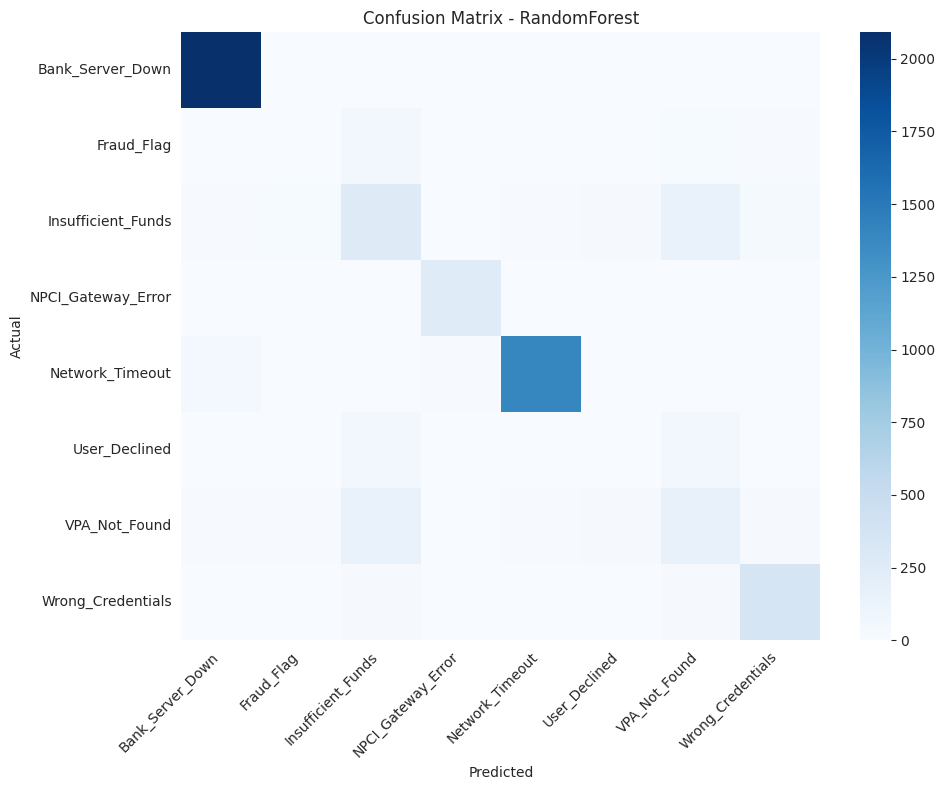

                    precision    recall  f1-score   support

  Bank_Server_Down       0.96      0.99      0.98      2102
        Fraud_Flag       0.05      0.02      0.03       109
Insufficient_Funds       0.46      0.49      0.48       544
NPCI_Gateway_Error       0.89      0.95      0.92       266
   Network_Timeout       0.97      0.95      0.96      1473
     User_Declined       0.12      0.05      0.07       159
     VPA_Not_Found       0.35      0.39      0.37       402
 Wrong_Credentials       0.81      0.83      0.82       440

          accuracy                           0.83      5495
         macro avg       0.58      0.59      0.58      5495
      weighted avg       0.81      0.83      0.82      5495



In [ ]:
y_pred = best_model.predict(X_test)
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, zero_division=0))


## 5) Real-Time Understanding Mode (Interactive Prediction)

Use the controls below to simulate a failed transaction and instantly see:
- Predicted root cause
- Top class probabilities

This is the dashboard-style learning section for practical understanding.


In [ ]:
# Widgets
amount_w = widgets.FloatSlider(value=5000, min=1, max=100000, step=100, description='Amount')
network_w = widgets.Dropdown(options=['4G', 'WiFi', '3G'], value='4G', description='Network')
os_w = widgets.Dropdown(options=['Android', 'iOS', 'Web'], value='Android', description='Device')
txn_w = widgets.Dropdown(options=['P2P', 'P2M'], value='P2P', description='Txn Type')
err_w = widgets.Dropdown(options=ERRORS[1:], value='E001', description='Error')
server_w = widgets.Dropdown(options=['healthy', 'degraded', 'down'], value='healthy', description='Bank Srv')
resp_w = widgets.FloatSlider(value=1800, min=50, max=9000, step=50, description='Resp(ms)')
retry_w = widgets.IntSlider(value=1, min=0, max=8, step=1, description='Retry')
hour_w = widgets.IntSlider(value=10, min=0, max=23, step=1, description='Hour')
dow_w = widgets.IntSlider(value=2, min=0, max=6, step=1, description='Day(0-6)')
npci_w = widgets.FloatSlider(value=70, min=1, max=600, step=1, description='NPCI Lat')
vpa1_w = widgets.IntSlider(value=120, min=0, max=499, step=1, description='PayerVPA')
vpa2_w = widgets.IntSlider(value=220, min=0, max=499, step=1, description='PayeeVPA')
pbank_w = widgets.Dropdown(options=list(le_payer.classes_), value=le_payer.classes_[0], description='PayerBk')
qbank_w = widgets.Dropdown(options=list(le_payee.classes_), value=le_payee.classes_[0], description='PayeeBk')

btn = widgets.Button(description='Predict Root Cause', button_style='success')
out = widgets.Output()

def infer(_):
    with out:
        clear_output()
        peak = int((9 <= hour_w.value <= 11) or (18 <= hour_w.value <= 21))
        weekend = int(dow_w.value >= 5)
        # approximate load from historical fail rates
        bank_load = float((df_fail['payer_bank'] == pbank_w.value).mean())

        row = pd.DataFrame([{
            'amount': amount_w.value,
            'payer_vpa_bucket': float(vpa1_w.value),
            'payee_vpa_bucket': float(vpa2_w.value),
            'transaction_type': txn_w.value,
            'device_os': os_w.value,
            'network_type': network_w.value,
            'error_code': err_w.value,
            'response_time_ms': resp_w.value,
            'retry_count': retry_w.value,
            'hour': hour_w.value,
            'day_of_week': dow_w.value,
            'bank_server_status': server_w.value,
            'npci_gateway_latency_ms': npci_w.value,
            'peak_hour': peak,
            'weekend': weekend,
            'bank_load_index': bank_load,
            'payer_bank_le': int(le_payer.transform([pbank_w.value])[0]),
            'payee_bank_le': int(le_payee.transform([qbank_w.value])[0]),
        }])

        pred = best_model.predict(row)[0]
        proba = best_model.predict_proba(row)[0]
        cls = best_model.named_steps['clf'].classes_
        top = pd.Series(proba, index=cls).sort_values(ascending=False).head(5)

        print('Predicted Root Cause:', pred)
        print('Top probabilities:')
        print(top.to_string())

btn.on_click(infer)

display(widgets.VBox([
    amount_w, network_w, os_w, txn_w, err_w, server_w,
    resp_w, retry_w, hour_w, dow_w, npci_w,
    vpa1_w, vpa2_w, pbank_w, qbank_w,
    btn, out
]))

## 6) Usefulness and Limitation of Work

### Usefulness
1. Banks and PSPs can auto-tag failure reasons, reducing manual triage workload.
2. NPCI operations can prioritize incidents from aggregated real-time failure intelligence.
3. Customers can receive clearer failure reasons quickly.
4. Fraud-related flags can be escalated faster.
5. Trends help reliability planning and preventive action.

### Limitations
1. Dataset is synthetic; production needs real governed bank/NPCI logs.
2. Sequential/cascading failures are not modeled (future scope: sequence models/LSTM).
3. Explainability here is model-feature importance, not full compliance-grade interpretability.
4. Real-time serving infra (sub-100ms SLA, monitoring, MLOps) is out of scope in this notebook.


## 7) Timeline Chart

Timeline derived from the PDF activities: literature, data generation, EDA, preprocessing, baseline and advanced modeling, tuning, explainability/comparison, reporting.


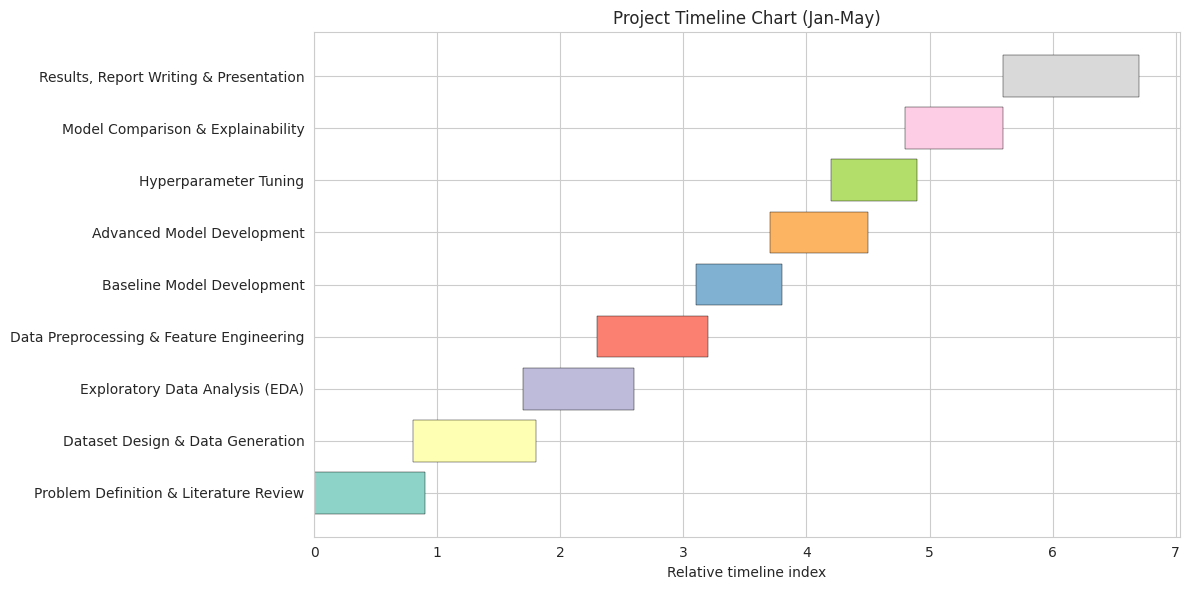

In [ ]:
tasks = [
    'Problem Definition & Literature Review',
    'Dataset Design & Data Generation',
    'Exploratory Data Analysis (EDA)',
    'Data Preprocessing & Feature Engineering',
    'Baseline Model Development',
    'Advanced Model Development',
    'Hyperparameter Tuning',
    'Model Comparison & Explainability',
    'Results, Report Writing & Presentation'
]
start = [0.0, 0.8, 1.7, 2.3, 3.1, 3.7, 4.2, 4.8, 5.6]
duration = [0.9, 1.0, 0.9, 0.9, 0.7, 0.8, 0.7, 0.8, 1.1]

plt.figure(figsize=(12, 6))
for i, (t, s, d) in enumerate(zip(tasks, start, duration)):
    plt.barh(t, d, left=s, color=plt.cm.Set3(i % 12), edgecolor='black', linewidth=0.3)

plt.title('Project Timeline Chart (Jan-May)')
plt.xlabel('Relative timeline index')
plt.tight_layout()
plt.show()


## 8) References

1. NPCI Annual Report 2024 (UPI statistics): https://www.npci.org.in
2. Sharma et al., Failure Classification in Real-Time Payment Systems, IEEE COMSNETS, 2022.
3. Gupta et al., Root Cause Analysis of Digital Payment Failures using Explainable AI, IJCAI FinTech Workshop, 2023.
4. Chen & Guestrin, XGBoost, KDD 2016.
5. Lundberg & Lee, SHAP, NeurIPS 2017.
6. UPI dataset generator reference: https://www.kaggle.com/code/skullagos5246/upi-transactions-generator
7. Imbalanced-learn SMOTE: https://imbalanced-learn.org
8. LightGBM docs: https://lightgbm.readthedocs.io
